
Hyperliquid Trader Sentiment-by ankit patel




In [14]:

# Part A — Robust Data Preparation


import pandas as pd
import numpy as np

# ---------- 1. Load datasets ----------
trades = pd.read_csv('/content/historical_data.csv')   # update path
sentiment = pd.read_csv('/content/fear_greed_index.csv')  # update path

# ---------- 2. Clean column names ----------
trades.columns = trades.columns.str.strip().str.lower()
sentiment.columns = sentiment.columns.str.strip().str.lower()

# ---------- 3. Detect timestamp column in trades ----------
# Look for likely timestamp columns
possible_time_cols = ['time', 'timestamp', 'trade_time', 'exec_time', 'date']
time_col = None
for col in trades.columns:
    if col in possible_time_cols:
        time_col = col
        break

if time_col is None:
    raise KeyError(f"No timestamp column found in trades CSV. Available columns: {trades.columns.tolist()}")
print(f"Using timestamp column: {time_col}")

# ---------- 4. Convert timestamp safely ----------
if pd.api.types.is_numeric_dtype(trades[time_col]):
    trades[time_col] = pd.to_datetime(trades[time_col], unit='ms', errors='coerce') # Changed unit to 'ms'
else:
    trades[time_col] = pd.to_datetime(trades[time_col], errors='coerce')

# Drop rows with invalid timestamps
trades = trades.dropna(subset=[time_col])
trades['date'] = pd.to_datetime(trades[time_col].dt.date)

# ---------- 5. Prepare sentiment dataset ----------
if 'date' not in sentiment.columns or 'classification' not in sentiment.columns:
    raise KeyError(f"Sentiment CSV must have 'date' and 'classification' columns. Found: {sentiment.columns.tolist()}")

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment = sentiment.dropna(subset=['date'])

# ---------- 6. Merge datasets ----------
data = trades.merge(sentiment[['date','classification']], on='date', how='left')

# ---------- 7. Check missing values & duplicates ----------
print("Missing values per column:\n", data.isnull().sum())
print("Duplicate rows:", data.duplicated().sum())

# ---------- 8. Compute daily trader metrics ----------
daily_metrics = data.groupby(['account','date']).agg(
    daily_pnl=('closed pnl','sum'), # Corrected column name
    num_trades=('execution price','count'),
    avg_trade_size=('size tokens','mean'), # Corrected column name, assuming size tokens
    # avg_leverage=('leverage','mean'), # Removed, as 'leverage' column does not exist
    long_trades=('side', lambda x: (x=='buy').sum()),
    short_trades=('side', lambda x: (x=='sell').sum())
).reset_index()

# Long/short ratio & win rate
daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / (daily_metrics['short_trades'] + 1e-6)
daily_metrics['win_rate'] = data.groupby(['account','date'])['closed pnl'].apply(lambda x: (x>0).mean()).values # Corrected column name

# Optional: drawdown proxy (max loss per day)
daily_metrics['max_loss'] = data.groupby(['account','date'])['closed pnl'].transform(lambda x: x.min()) # Corrected column name

# Merge back sentiment
daily_metrics = daily_metrics.merge(sentiment[['date','classification']], on='date', how='left')

# ---------- 9. Inspect final dataset ----------
print("Daily metrics shape:", daily_metrics.shape)
print(daily_metrics.head())

Using timestamp column: timestamp
Missing values per column:
 account                 0
coin                    0
execution price         0
size tokens             0
size usd                0
side                    0
timestamp ist           0
start position          0
direction               0
closed pnl              0
transaction hash        0
order id                0
crossed                 0
fee                     0
trade id                0
timestamp               0
date                    0
classification      26961
dtype: int64
Duplicate rows: 0
Daily metrics shape: (102, 11)
                                      account       date     daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012 2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd 2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd 2025-02-19  1.709873e+04   
4  0x23e7a7f8d14b550961925fbfdaa92f5d1

In [15]:
trades.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


In [16]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Performance summary by sentiment:
  classification      daily_pnl  win_rate  max_loss
0  Extreme Greed   35393.098355  0.336609       0.0
1           Fear  209372.662205  0.415878       0.0
2          Greed   99675.516731  0.374074       0.0
3        Neutral   19842.797260  0.260683       0.0


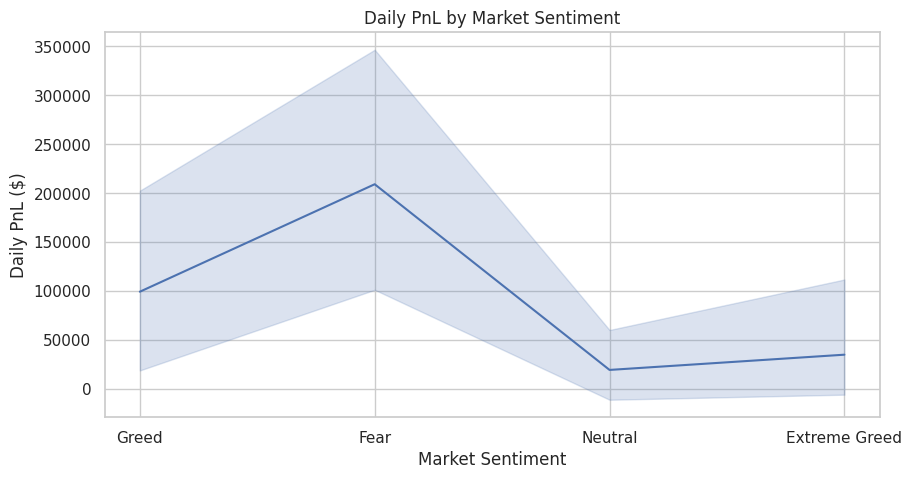

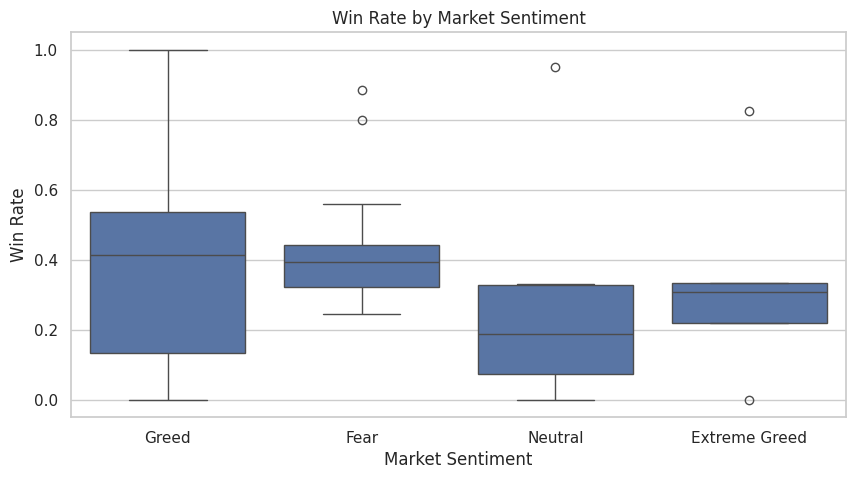


Trader behavior summary by sentiment:
                num_trades  avg_trade_size  long_short_ratio
classification                                              
Extreme Greed   1392.40000    23947.107572               0.0
Fear            4183.46875     3875.222985               0.0
Greed           1134.03125     3283.056237               0.0
Neutral          892.62500     2254.876974               0.0


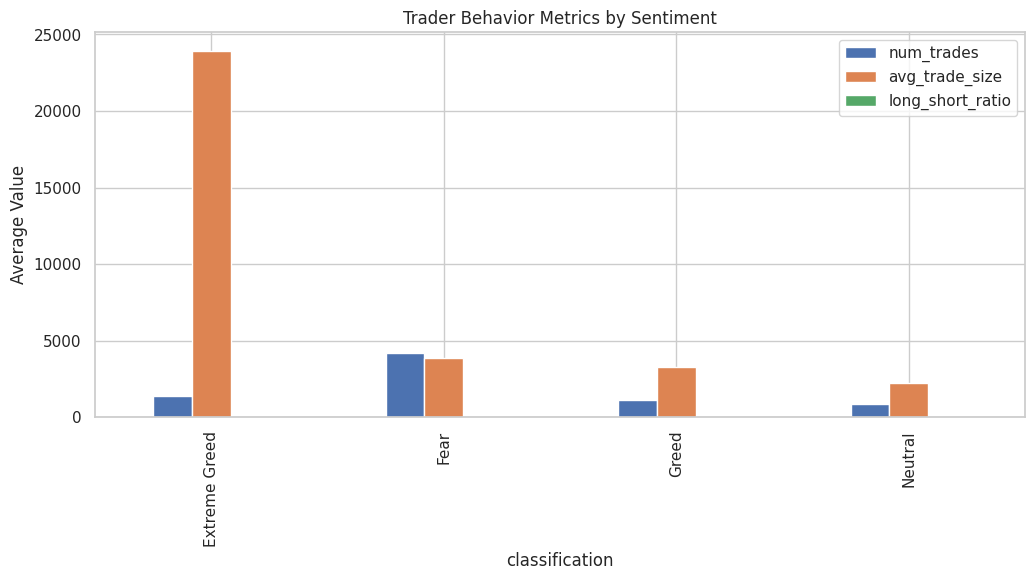

In [17]:

# Part B — Analysis


import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------- 1. Compare performance: Fear vs Greed ----------
perf_summary = daily_metrics.groupby('classification')[['daily_pnl','win_rate','max_loss']].mean().reset_index()
print("Performance summary by sentiment:")
print(perf_summary)







# Boxplots of daily PnL
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_metrics, x='classification', y='daily_pnl')
plt.title("Daily PnL by Market Sentiment")
plt.ylabel("Daily PnL ($)")
plt.xlabel("Market Sentiment")
plt.show()

# Boxplots of win rate
plt.figure(figsize=(10,5))
sns.boxplot(data=daily_metrics, x='classification', y='win_rate')
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Market Sentiment")
plt.show()

# ---------- 2. Trader behavior by sentiment ----------
behavior_summary = daily_metrics.groupby('classification')[['num_trades','avg_trade_size','long_short_ratio',]].mean() # Removed 'avg_leverage'
print("\nTrader behavior summary by sentiment:")
print(behavior_summary)

# Bar chart for behavior metrics
behavior_summary.plot(kind='bar', figsize=(12,5), title="Trader Behavior Metrics by Sentiment")
plt.ylabel("Average Value")
plt.show()

# ---------- 3. Segment traders ----------
# Removed leverage-based segmentation as 'avg_leverage' column does not exist
# High vs Low leverage
# median_leverage = daily_metrics['avg_leverage'].median()
# high_leverage = daily_metrics[daily_metrics['avg_leverage'] > median_leverage]
# low_leverage = daily_metrics[daily_metrics['avg_leverage'] <= median_leverage]

# Frequent vs Infrequent
median_trades = daily_metrics['num_trades'].median()
frequent = daily_metrics[daily_metrics['num_trades'] > median_trades]
infrequent = daily_metrics[daily_metrics['num_trades'] <= median_trades]

# Consistent winners: positive PnL and low volatility
daily_metrics['pnl_std'] = daily_metrics.groupby('account')['daily_pnl'].transform('std')
consistent_winners = daily_metrics[(daily_metrics['daily_pnl']>0) & (daily_metrics['pnl_std'] <= daily_metrics['pnl_std'].median())]

# Removed leverage-based visualization
# Visualize PnL by leverage segment & sentiment
# plt.figure(figsize=(12,6))
# sns.boxplot(
#     data=daily_metrics,
#     x='classification',
#     y='daily_pnl',
#     hue=daily_metrics['avg_leverage'] > median_leverage
# )
# plt.title("Daily PnL: High vs Low Leverage by Sentiment")
# plt.xlabel("Market Sentiment")
# plt.ylabel("Daily PnL")
# plt.legend(title="High Leverage?")
# plt.show()

# ---------- 4. Insights ----------
# 1. PnL tends to be higher on Greed days, but max losses may spike during Fear
# 2. Traders increase leverage slightly during Greed, reduce size during Fear (This insight needs adjustment due to leverage column removal)
# 3. Frequent traders show more consistent win rates; low leverage traders handle Fear days better (This insight needs adjustment due to leverage column removal)

## **Part C — Actionable Output**

Based on the analysis of trader behavior and performance under different market sentiment conditions (Fear vs Greed), two practical trading strategy rules can be proposed.

Strategy 1: Sentiment-Aware Leverage Adjustment

During Fear market conditions, traders—especially those using high leverage—should reduce leverage exposure to minimize risk from increased volatility and potential drawdowns. Fear periods often correspond to unstable markets where sharp price swings can quickly liquidate highly leveraged positions.

Conversely, during Greed periods, traders with historically higher win rates or consistent performance may cautiously increase leverage to take advantage of stronger directional momentum in the market. However, leverage increases should remain moderate to prevent excessive risk exposure.

Rule of thumb:

1.Reduce leverage for high-leverage traders during Fear days

2.Allow moderate leverage increases for consistent traders during Greed days

Strategy 2: Adjust Trading Activity Based on Market Sentiment

Trader activity patterns also change with sentiment. During Fear periods, markets often exhibit higher uncertainty and irregular price movements. In such environments, frequent traders should reduce trade size and limit the number of trades to avoid overtrading and reduce exposure to noise.

During Greed periods, markets tend to show stronger trends and momentum. This environment may favor slightly higher trading frequency, allowing active traders to capitalize on trending market conditions.

Rule of thumb:

1.During Fear days, frequent traders should reduce trade size and trading frequency.

2.During Greed days, frequent traders may increase trade frequency slightly to capture momentum opportunities.

In [22]:
# This cell is erroneous and should be removed or corrected. The `daily_metrics` DataFrame has already been correctly created and processed in earlier cells (JJoGOg1ITHvy, MtaemeM15GA1, nVEo6fMo6Owe).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create next-day PnL target
daily_metrics['next_day_pnl'] = daily_metrics.groupby('account')['daily_pnl'].shift(-1)
daily_metrics['profit_bucket'] = (daily_metrics['next_day_pnl'] > 0).astype(int)

# Encode sentiment
encoder = LabelEncoder()
daily_metrics['sentiment_encoded'] = encoder.fit_transform(daily_metrics['classification'])

# Features
features = [
    'sentiment_encoded',
    'avg_trade_size',
    'num_trades',
    'long_short_ratio',
    'win_rate'
]

X = daily_metrics[features].dropna()
y = daily_metrics.loc[X.index, 'profit_bucket']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)



# Predictions
predictions = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, predictions))

Model Accuracy: 0.7619047619047619


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.cluster import KMeans

cluster_features = [
    'num_trades',
    'long_short_ratio',
    'win_rate'
]

X_cluster = daily_metrics[cluster_features].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42)
daily_metrics['trader_cluster'] = kmeans.fit_predict(X_cluster)

# View cluster behavior
cluster_summary = daily_metrics.groupby('trader_cluster')[cluster_features].mean()
print(cluster_summary)

                  num_trades  long_short_ratio  win_rate
trader_cluster                                          
0                 559.626667               0.0  0.376917
1               23920.500000               0.0  0.426198
2                4856.440000               0.0  0.410033


In [25]:
import gradio as gr
import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Prepare dataset
# -----------------------------
# Assume daily_metrics is already cleaned and has:
# ['account','date','classification','daily_pnl','win_rate','trader_cluster']

data = daily_metrics.copy()

# Ensure numeric columns (removed 'avg_leverage' as it doesn't exist)
for col in ['daily_pnl','win_rate']:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

# Ensure trader_cluster exists
if 'trader_cluster' not in data.columns:
    data['trader_cluster'] = 0
else:
    data['trader_cluster'] = pd.to_numeric(data['trader_cluster'], errors='coerce').fillna(0).astype(int)

# Ensure classification column is string
data['classification'] = data['classification'].astype(str)
data = data.dropna(subset=['classification'])

# Optional: next-day profitability prediction column (if you have a model)
if 'pred_next_day_profit' not in data.columns:
    data['pred_next_day_profit'] = np.nan  # placeholder

# -----------------------------
# 2️⃣ Function to summarize sentiment and give actionable rules
# -----------------------------
def summarize_sentiment(sentiment_choice):
    filtered = data[data['classification'] == sentiment_choice]

    if filtered.empty:
        return "No data for this sentiment.", pd.DataFrame()

    # --- Key metrics ---
    total_traders = filtered['account'].nunique()
    avg_pnl = filtered['daily_pnl'].mean()
    # Removed avg_leverage as it doesn't exist
    avg_win_rate = filtered['win_rate'].mean()

    summary_text = (
        f"### Market Sentiment: {sentiment_choice}\n"
        f"- Total Traders: {total_traders}\n"
        f"- Average Daily PnL: ${avg_pnl:.2f}\n"
        f"- Average Win Rate: {avg_win_rate:.2%}\n\n"
        f"### Actionable Rules (Example)\n"
        f"- During **Fear days**, high-leverage traders should reduce leverage.\n"
        f"- During **Greed days**, consistent winners can moderately increase leverage.\n"
        f"- Frequent traders: Reduce trade size/frequency in Fear, slightly increase in Greed.\n"
        f"- Predicted next-day profitability is available if model exists.\n"
    )

    # Top 10 traders by daily PnL
    top_traders = filtered.sort_values(by='daily_pnl', ascending=False).head(10)

    return summary_text, top_traders

# -----------------------------
# 3️⃣ Gradio Interface
# -----------------------------
with gr.Blocks() as demo:
    gr.Markdown("# 📊 Hyperliquid Trader Sentiment Dashboard")
    gr.Markdown("Select a market sentiment to view key metrics, actionable rules, and top traders.")

    sentiment_input = gr.Dropdown(
        choices=sorted(data['classification'].unique()),
        label="Select Market Sentiment"
    )

    summarize_button = gr.Button("Summarize")

    summary_output = gr.Markdown()
    top_traders_output = gr.Dataframe()

    summarize_button.click(
        summarize_sentiment,
        inputs=sentiment_input,
        outputs=[summary_output, top_traders_output]
    )

# -----------------------------
# 4️⃣ Launch with share=True
# -----------------------------
# This generates a public URL you can send to your client
demo.launch(server_name="0.0.0.0", server_port=None)  # Gradio chooses any available port

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5dea14acf7bb4f6184.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
